# First use the HPLC_molecule_creation script if it is the frist analysis load
## Load Metadata

The spreadsheet `metadata_v2.xlsx` defines the initial concentrations of all molecules present in the respective assay. 
Products should be added with a concentration of 0. Empty cells are not added to the analyzer.

In [1]:
import pandas as pd
from pathlib import Path

# load metadata as dataframe
metadata_path = "input/metadata_v2.xlsx"
metadata_df = pd.read_excel(metadata_path)
metadata_df = metadata_df.dropna(axis='columns')

# set 'experiment_name' as index
metadata_df.set_index("experiment_name", inplace=True)

metadata_df

,reaction_vol [mL],temperature,pH,EbPPK,AMP,ADP,ATP,TrisHCL,MgCl2,PolyP
experiment_name,,,,,,,,,,
Assay 6.1,1,37,8,0.00001,5,0,0,50,10,50
Assay 6.2,1,37,8,0.00001,5,0,0,50,10,50
Assay 6.3,1,37,8,0.00001,5,0,0,50,10,50



## Load Molecules

In [2]:
from chromhandler import Handler, Molecule, Protein, to_enzymeml
from pathlib import Path
import numpy as np
from utility import plot_replicates

# create list to add molecules to
molecules = []
retention_times_updated = {"AMP": 1.25, "ADP": 3.56, "ATP": 5.73, "GMP": 1.78, "GDP": 4.27, "GTP": 7.6}
# define path to the calibration molecules
standard_dir = Path("result/calib_molecules/20251016_standards")

# loop over all the json files in the calibration molecules folder
# and create molecule objects
for molecule_path in standard_dir.glob("*.json"):
    molecule = Molecule.read_json(molecule_path)
    if molecule.id in retention_times_updated:
        molecule.retention_time = retention_times_updated[molecule.id]
    molecules.append(molecule)



molecule_dir = Path("result/calib_molecules/")

for molecule_path in molecule_dir.glob("*.json"):
    molecule = Molecule.read_json(molecule_path)
    molecules.append(molecule)

print(f"Loaded {len(molecules)} with IDs {[m.id for m in molecules]}")

SyntaxError: '(' was never closed (plot.py, line 204)

## Load Proteins

In [ ]:
proteins = []

for protein_path in Path("result/proteins").glob("*.json"):
    protein = Protein.read_json(protein_path)
    proteins.append(protein)

print(f"Loaded {len(proteins)} with names {[p.name for p in proteins]}")

Loaded 4 with names ['EaGK', 'EbPPK', 'ScADK', 'tmmcGAS']


#### Filter the molecules based on the the metadata

# Process timecours data 

In [ ]:
sample_dir = Path("data/time_sample/2025.10.28 EbPPK Assay 6 MB D127R GMP_AMP short Data")
print(f"Found {len(list(sample_dir.iterdir()))} time samples in {sample_dir}")

# loop over all the time samples and create the ChromAnalyzer objects
handlers = []
for time_samples in sample_dir.iterdir():
    path = str(time_samples)
    analyzer = Handler.read_agilent(
        path=path,
        ph=metadata_df.loc[str(time_samples.name), "pH"],
        temperature=metadata_df.loc[str(time_samples.name), "temperature"],
        mode="timecourse",
    )

    # add molecule data to the analyzer
    for molecule in molecules:
        if molecule.id not in metadata_df.columns:
            continue
        init_conc = metadata_df.loc[str(time_samples.name), molecule.id]

        # set constant molecules (concentration does not change over time)
        if molecule.id in ["MgCl2", "TrisHCL"]:
            molecule.constant = True

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_molecule(
                molecule,
                init_conc=metadata_df.loc[str(time_samples.name), molecule.id],
                conc_unit="umol / L",
            )

    # add protein data to the analyzer
    for protein in proteins:
        if protein.name not in metadata_df.columns:
            continue
        init_conc = metadata_df.loc[str(time_samples.name), protein.name]

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_protein(
                protein,
                init_conc=metadata_df.loc[str(time_samples.name), protein.name],
                conc_unit="umol / L",
            )

    analyzer.assign_all_peaks()

    handlers.append(analyzer)

Found 3 time samples in data\time_sample\2025.10.28 EbPPK Assay 6 MB D127R GMP_AMP short Data


               🎯 Peak Assignment Summary of Assay 6.1               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ ADP (5'-Adp)                  │ ✅ Success │ (8/8) peaks assigned │
│ AMP (Adenosine Monophosphate) │ ✅ Success │ (8/8) peaks assigned │
│ ATP (5'-Atp)                  │ 🟡 Partial │ (7/8) peaks assigned │
└───────────────────────────────┴────────────┴──────────────────────┘

               🎯 Peak Assignment Summary of Assay 6.2               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ ADP (5'-Adp)                  │ ✅ Success │ (8/8) peaks assigned │
│ AMP (Adenosine Monophosphate) │ ✅ Success │ (8/8) peaks assigned │
│ ATP (5'-Atp)                  │ 🟡 Partial │ (7/8) peaks assigned │
└───────────────────────────────┴────────────┴──────────────────────┘

               🎯 Peak Assignment Summary of Assay 6.3               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ ADP (5'-Adp)                  │ 🟡 Partial │ (7/8) peaks assigned │
│ AMP (Adenosine Monophosphate) │ 🟡 Partial │ (7/8) peaks assigned │
│ ATP (5'-Atp)                  │ 🟡 Partial │ (7/8) peaks assigned │
└───────────────────────────────┴────────────┴──────────────────────┘

## Create EnzymeML Document including 3 replicates



In [ ]:
import pyenzyme as pe

# add the metadata to the timecourse data
timecourse_enzymeML = to_enzymeml(
    document_name="Assay 6 MB D127R AMP short",
    handlers=handlers,
    calculate_concentration=True,
    extrapolate=False,
)

# add vessel
vessel = pe.Vessel(
    id="v1",
    name="Eppendorf Tube",
    volume="1",
    unit="ml",
)
timecourse_enzymeML.vessels = [vessel]


# identify replicates
timecourse_enzymeML = pe.group_measurements(timecourse_enzymeML, attribute="prepared")

# show summary of document
pe.summary(timecourse_enzymeML)

# save the enzymeML document to file
pe.write_enzymeml(
    timecourse_enzymeML, f"result/enzymeML/{timecourse_enzymeML.name}.json"
)

📋 EnzymeML Document Summary

╭─ 📄 Document Overview ──────────────────────────────────────────────────────────────────────────────────────────╮
│ Name: Assay 6 MB D127R AMP short                                                                                │
│ Version: 2                                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

    📊 Component Counts                                                       
┏━━━━━━━━━━━━━━━━━┳━━━━━━━┓                                                   
┃ Component       ┃ Count ┃                                                   
┡━━━━━━━━━━━━━━━━━╇━━━━━━━┩                                                   
│ Vessels         │     1 │                                                   
│ Proteins        │     0 │                                                   
│ Complexes       │     0 │                                                   
│ Small Molecules │     6 │                                                   
│ Reactions       │     0 │                                                   
│ Measurements    │     3 │                                                   
│ Equations       │     0 │                                                   
│ Parameters      │     0 │                                                   
└─────────────────┴───────┘                                                   
                              🧬 Species Details                              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Type           ┃ ID                    ┃ Name                    ┃ Details ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Small Molecule │ ADP                   │ 5'-Adp                  │ —       │
│ Small Molecule │ AMP                   │ Adenosine Monophosphate │ —       │
│ Small Molecule │ ATP                   │ 5'-Atp                  │ —       │
│ Small Molecule │ MgCl2                 │ Magnesium Chloride      │ —       │
│ Small Molecule │ PolyP                 │ Sodium Polyphosphate    │ —       │
│                │ ... +1 more molecules │                         │         │
└────────────────┴───────────────────────┴─────────────────────────┴─────────┘

                🧪 Vessels                 
┏━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ ID ┃ Name           ┃ Volume ┃ Constant ┃
┡━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ v1 │ Eppendorf Tube │ 1.0 ml │    ✓     │
└────┴────────────────┴────────┴──────────┘

                                📈 Measurements                                 
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ID           ┃ Name                 ┃ Species Data ┃ Conditions              ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Assay 6.1    │ Assay 6.1            │      6       │ pH: 8.0 | T: 37.0 deg_C │
│ Assay 6.2    │ Assay 6.2            │      6       │ pH: 8.0 | T: 37.0 deg_C │
│ Assay 6.3    │ Assay 6.3            │      6       │ pH: 8.0 | T: 37.0 deg_C │
└──────────────┴──────────────────────┴──────────────┴─────────────────────────┘

EnzymeML document written to result\enzymeML\Assay 6 MB D127R AMP short.json

## Visualize

For visualization the build-in `plot` method of the `pyenzyme` package can be used.

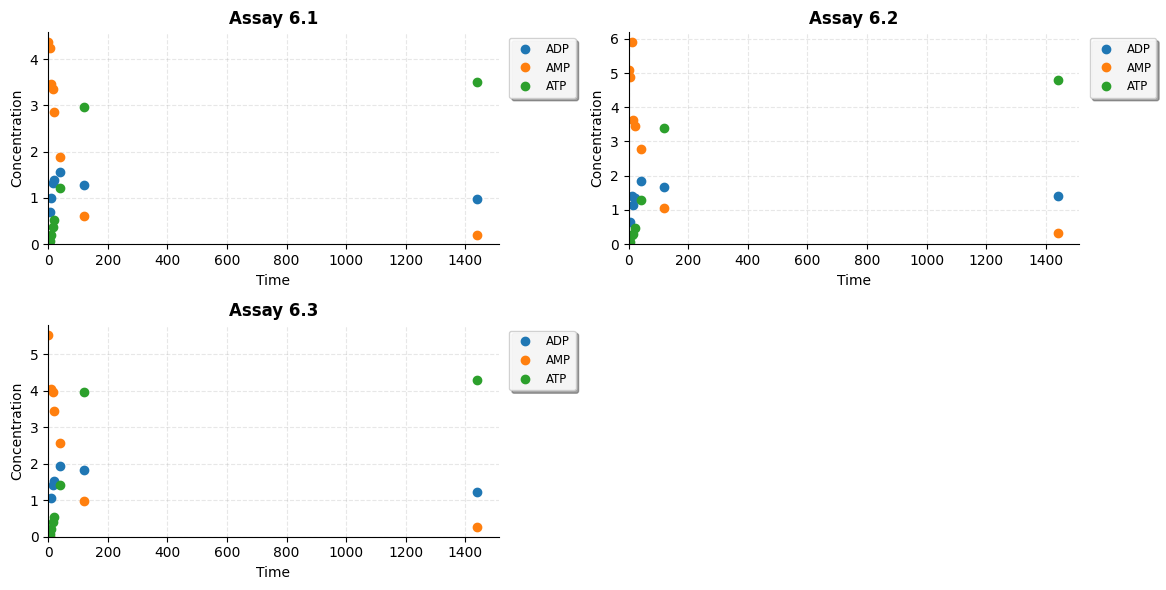

In [ ]:
fig, ax = pe.plot(timecourse_enzymeML)
for axe in ax:
    axe.set_xlim(0)
    axe.set_ylim(0)

Furthermore, the `plot_replicates` function can be used to plot the replicates. It aggregates replicates and plots the mean±std per species as an errorbar plot. The function can be modified by manipulating the code in `utility/plot.py`.

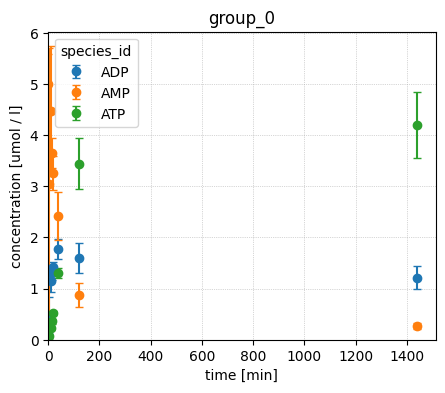

In [ ]:
fig, axes = plot_replicates(timecourse_enzymeML)
for axe in axes:
    axe.set_xlim(0)
    axe.set_ylim(0)

fig.savefig("result/figures/Assay_6_replicates_overview.png", dpi=300)

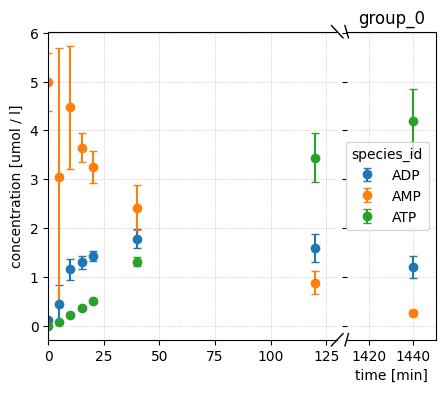

In [ ]:
from utility import plot_replicates_broken_axis
fig, axes = plot_replicates_broken_axis(doc= timecourse_enzymeML, x_ranges=[(0,130),(1410,1450)], breakmark_size=0.02)
for axe in axes:
    axe.set_xlim(0)
    axe.set_ylim(0)

fig.savefig("result/figures/Assay_6_replicates_overview.png", dpi=300)